# Post-Fault Rotor Oscillation on an SMIB System

When a synchronous generator connected to an infinite bus experiences a
transient fault, the rotor swings away from its equilibrium angle and then
oscillates as the synchronizing torque pulls it back.  The amplitude and
persistence of these oscillations depend on the machine inertia, network
strength, and the damping provided by flux dynamics and controllers.

This notebook constructs a single-machine infinite-bus (SMIB) system from
scratch using the ANDES v2 API, applies a three-phase fault, and visualizes
the resulting electromechanical oscillation.  The system is intentionally
configured with **zero mechanical damping** ($D = 0$) to produce a
slowly-decaying swing that motivates the need for supplementary damping
control — a task well suited to reinforcement learning, explored in a
companion notebook.

In [1]:
%matplotlib inline

import numpy as np
from matplotlib import pyplot as plt

import andes

andes.config_logger(stream_level=30)

## Build the SMIB System

The system has two buses connected by a single transmission line:

| Bus | Role | Model |
|-|-|-|
| 1 | Generator bus | GENROU (6th-order salient-pole machine) |
| 2 | Infinite bus | GENCLS with very large inertia ($M = 6 \times 10^7$) |

The generator is equipped with a TGOV1 governor and an EXST1 exciter.
Mechanical damping is set to $D = 0$ so that all damping comes from
the electromagnetic flux dynamics inherent in the GENROU model.

In [2]:
ss = andes.System(default_config=True)
ss.undill()

# --- network ---
ss.add("Bus", idx=1, name="Gen Bus", Vn=20.0, v0=1.05)
ss.add("Bus", idx=2, name="Inf Bus", Vn=20.0, v0=1.0)

ss.add("Line", idx=1, bus1=1, bus2=2, Vn1=20.0, Vn2=20.0,
       r=0.003, x=0.25, b=0.0)

# --- static generators (PFlow placeholders) ---
ss.add("PV",    idx=1, bus=1, Vn=20.0, p0=0.9, q0=0.0, v0=1.05)
ss.add("Slack", idx=2, bus=2, Vn=20.0, v0=1.0)

# --- infinite bus: very large GENCLS ---
ss.add("GENCLS", idx="INF", bus=2, gen=2, Sn=1e9, Vn=20.0,
       M=6e7, D=2e7, xd1=1e-9)

# --- finite machine: GENROU, D=0 ---
ss.add("GENROU", idx="GEN1", bus=1, gen=1, Sn=100, Vn=20.0,
       M=6.0, D=0.0,
       xd=1.8, xd1=0.3, xd2=0.25, Td10=8.0, Td20=0.03,
       xq=1.7, xq1=0.55, xq2=0.25, Tq10=0.4, Tq20=0.05,
       ra=0.003, xl=0.2)

# --- governor ---
ss.add("TGOV1", idx="TG1", syn="GEN1",
       T1=0.5, T2=2.0, T3=7.0, VMAX=99)

# --- exciter ---
ss.add("EXST1", idx="EX1", syn="GEN1", TR=0.02, KA=50.0)

# --- three-phase fault: 6 cycles on the generator bus ---
ss.add("Fault", idx="Flt1", bus=1, tf=1.0, tc=1.1, xf=1e-4)

ss.setup()
print(f"System: {ss.Bus.n} buses, {ss.Line.n} line, "
      f"{ss.GENROU.n} GENROU, {ss.GENCLS.n} GENCLS")

System: 2 buses, 1 line, 1 GENROU, 1 GENCLS


## Power Flow

Solve for the initial steady-state operating point.

In [3]:
ss.PFlow.run()

print(f"Bus voltages:      {ss.Bus.v.v}")
print(f"Bus angles (deg):  {np.rad2deg(ss.Bus.a.v)}")
print(f"Generator P = {ss.PV.p0.v[0]:.3f} pu on {ss.config.mva:.0f} MVA base")

Bus voltages:      [1.05 1.  ]
Bus angles (deg):  [1.23240246e+01 5.59782271e-14]
Generator P = 0.900 pu on 100 MVA base


## Apply a Three-Phase Fault and Run TDS

A solid three-phase fault ($X_f = 10^{-4}$ pu) is applied at the generator
bus at $t = 1.0$ s and cleared at $t = 1.1$ s (6 cycles at 60 Hz).
This drives the rotor angle far from equilibrium and excites the
electromechanical oscillation mode.

In [4]:
ss.TDS.config.tf = 15.0
ss.TDS.run()

  0%|          | 0/100 [00:00<?, ?%/s]

True

## Rotor Speed Response

The generator rotor speed $\omega$ deviates from nominal (1.0 pu) after
the fault is cleared.  With $D = 0$, the only source of damping is the
electromagnetic interaction between the rotor flux linkages and the
stator currents — an effect captured by the GENROU sub-transient model
but absent in the classical (GENCLS) model.

In [5]:
ts_omega = ss.TDS.get_timeseries(ss.GENROU.omega)
ts_delta = ss.TDS.get_timeseries(ss.GENROU.delta)

t = ts_omega.index.values
omega = ts_omega.values.flatten()
delta_deg = np.rad2deg(ts_delta.values.flatten())
freq_hz = omega * ss.config.freq        # convert to Hz
delta_omega = omega - 1.0               # deviation from nominal

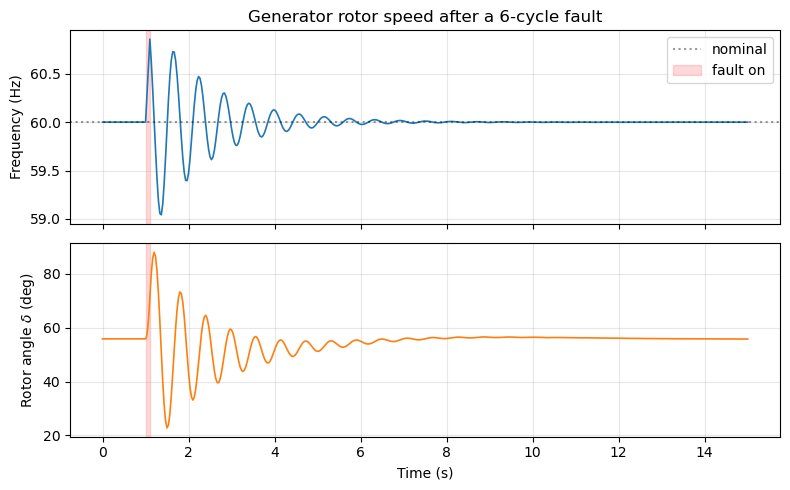

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)

# --- rotor speed ---
ax = axes[0]
ax.plot(t, freq_hz, linewidth=1.2)
ax.axhline(ss.config.freq, color="k", linestyle=":", alpha=0.4, label="nominal")
ax.axvspan(1.0, 1.1, color="red", alpha=0.15, label="fault on")
ax.set_ylabel("Frequency (Hz)")
ax.legend(loc="upper right")
ax.set_title("Generator rotor speed after a 6-cycle fault")
ax.grid(True, alpha=0.3)

# --- rotor angle ---
ax = axes[1]
ax.plot(t, delta_deg, linewidth=1.2, color="C1")
ax.axvspan(1.0, 1.1, color="red", alpha=0.15)
ax.set_ylabel("Rotor angle $\\delta$ (deg)")
ax.set_xlabel("Time (s)")
ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## Quantify the Oscillation Decay

We measure the peak-to-peak amplitude of the $\omega$ deviation at
successive swings.  The ratio between consecutive peaks gives the
per-cycle damping factor; the number of swings until the amplitude
drops below a threshold quantifies the settling time.

In [7]:
from scipy.signal import find_peaks

# analyse only the post-fault ring-down (t > 1.2 s)
mask = t > 1.2
t_pf, dev_pf = t[mask], np.abs(delta_omega[mask])

peaks, _ = find_peaks(dev_pf, distance=20)
peak_t = t_pf[peaks]
peak_amp = dev_pf[peaks]

# settling threshold: 0.1 % of nominal speed
threshold = 1e-3
settled_mask = peak_amp < threshold
if settled_mask.any():
    settle_idx = np.argmax(settled_mask)
    settle_time = peak_t[settle_idx] - 1.1   # seconds after fault clearing
    print(f"Settling time (|Δω| < {threshold}):  {settle_time:.1f} s "
          f"after fault clearing")
else:
    print("Oscillation has NOT settled within the simulation window.")

print(f"\nPeak-by-peak decay:")
print(f"{'Swing':>5s}  {'Time (s)':>8s}  {'|Δω| (pu)':>10s}  {'Decay ratio':>12s}")
for i in range(min(8, len(peak_amp))):
    ratio = f"{peak_amp[i]/peak_amp[0]:.4f}" if i > 0 else "—"
    print(f"{i+1:5d}  {peak_t[i]:8.2f}  {peak_amp[i]:10.6f}  {ratio:>12s}")

Settling time (|Δω| < 0.001):  3.8 s after fault clearing

Peak-by-peak decay:
Swing  Time (s)   |Δω| (pu)   Decay ratio
    1      1.37    0.015958             —
    2      2.23    0.007851        0.4920
    3      3.10    0.004004        0.2509
    4      4.00    0.002096        0.1314
    5      4.87    0.000998        0.0625
    6      5.73    0.000624        0.0391
    7      6.93    0.000282        0.0177
    8      8.10    0.000126        0.0079


## Phase Portrait

The $(\delta, \omega)$ phase portrait reveals the trajectory of the
rotor state.  A damped oscillation spirals inward toward the equilibrium
point; an undamped one would trace a closed orbit.

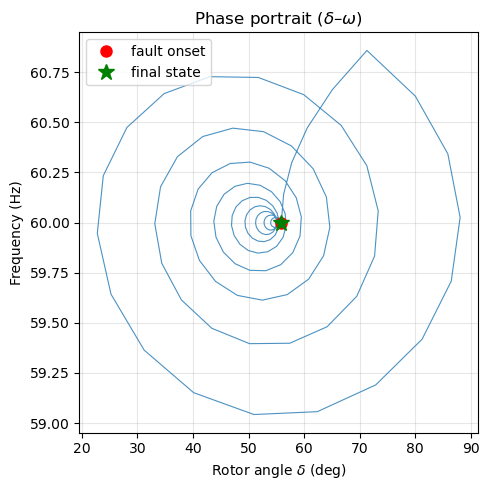

In [8]:
mask_ph = t >= 1.0  # from fault onset onward

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(delta_deg[mask_ph], freq_hz[mask_ph], linewidth=0.8, alpha=0.8)
ax.plot(delta_deg[mask_ph][0], freq_hz[mask_ph][0],
        "ro", markersize=8, label="fault onset")
ax.plot(delta_deg[mask_ph][-1], freq_hz[mask_ph][-1],
        "g*", markersize=12, label="final state")
ax.set_xlabel("Rotor angle $\\delta$ (deg)")
ax.set_ylabel("Frequency (Hz)")
ax.set_title("Phase portrait ($\\delta$–$\\omega$)")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Terminal Voltage and Exciter Response

The exciter (EXST1) regulates the terminal voltage during and after the
fault.  Its action also contributes a small component of electrical
damping torque.

In [9]:
ts_vt = ss.TDS.get_timeseries(ss.GENROU.v)     # terminal voltage
ts_vf = ss.TDS.get_timeseries(ss.GENROU.vf)    # field voltage (exciter output)
ts_pe = ss.TDS.get_timeseries(ss.GENROU.Pe)     # electrical power

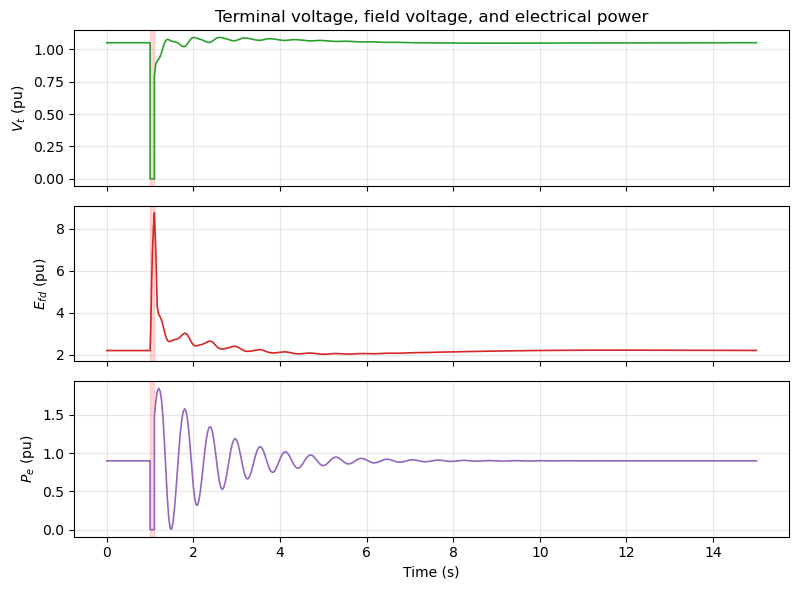

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(8, 6), sharex=True)

ax = axes[0]
ax.plot(t, ts_vt.values.flatten(), linewidth=1.2, color="C2")
ax.axvspan(1.0, 1.1, color="red", alpha=0.15)
ax.set_ylabel("$V_t$ (pu)")
ax.set_title("Terminal voltage, field voltage, and electrical power")
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(t, ts_vf.values.flatten(), linewidth=1.2, color="C3")
ax.axvspan(1.0, 1.1, color="red", alpha=0.15)
ax.set_ylabel("$E_{fd}$ (pu)")
ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(t, ts_pe.values.flatten(), linewidth=1.2, color="C4")
ax.axvspan(1.0, 1.1, color="red", alpha=0.15)
ax.set_ylabel("$P_e$ (pu)")
ax.set_xlabel("Time (s)")
ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## Toward Supplementary Damping Control

The 6-cycle fault on this SMIB system excites a ~1.1 Hz electromechanical
oscillation mode.  With $D = 0$ (no explicit mechanical damping), the
oscillation takes roughly **4 seconds** to settle below 0.1% speed
deviation, damped only by the GENROU flux dynamics and the exciter.

In larger interconnected systems, inter-area oscillation modes can be
far less damped — and in some operating conditions, negatively damped
(growing oscillations).  This motivates supplementary damping controllers.

Below we use reinforcement learning to train a controller that injects
auxiliary mechanical power $p_\text{aux}$ through the governor to damp
the oscillation faster, learning the optimal policy purely from simulation.

## RL Environment Setup

ANDES provides `AndesEnv`, a [Gymnasium](https://gymnasium.farama.org/)-compatible
environment that wraps the time-domain simulator.  Key design choices:

| Element | Choice | Rationale |
|-|-|-|
| Observation | $(\omega,\; \delta)$ | Speed *and* angle give the agent full swing-equation state |
| Action | $p_\text{aux} \in [-0.1, 0.1]$ pu | Auxiliary power injected via the governor |
| Reward | $-(f_\text{dev}^2 + 0.1\, p_\text{aux}^2)$ | Penalise frequency deviation (Hz) and control effort |
| Step interval | $\Delta t = 0.1$ s | ~11 control actions per oscillation cycle |
| Episode | $t = 1.2$ s to $7.2$ s | Start after fault clears, run 6 s of ring-down |

Each `reset()` uses `TDS.reinit()` (~1 ms) instead of reloading the case
from disk, enabling hundreds of episodes per minute.

In [11]:
from pathlib import Path
from andes.rl import AndesEnv
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback

CASE = str(Path("cases/smib/smib_rl.xlsx"))

In [12]:
def reward_fn(obs, action, env):
    """Penalise frequency deviation (in Hz) and control effort."""
    freq_dev_hz = (obs[0] - 1.0) * 60.0
    return -float(freq_dev_hz ** 2 + 0.1 * action[0] ** 2)


def disturbance_fn(env):
    """Fast-forward the simulation past the fault (cleared at t = 1.1 s)."""
    env.ss.TDS.config.tf = 1.2
    env.ss.TDS.run(no_summary=True)


env = AndesEnv(
    case=CASE,
    obs=[("GENROU", "omega"), ("GENROU", "delta")],
    acts=[("SynGen", "paux", ["GEN1"])],   # control only the finite machine
    reward_fn=reward_fn,
    dt=0.1,
    tf=7.2,
    disturbance_fn=disturbance_fn,
    action_low=-0.1,
    action_high=0.1,
)

print(f"Observation space: {env.observation_space}")
print(f"Action space:      {env.action_space}")
print(f"Steps per episode: {int((7.2 - 1.2) / 0.1)}")

Observation space: Box(-inf, inf, (2,), float32)
Action space:      Box(-0.1, 0.1, (1,), float32)
Steps per episode: 60


## No-Control Baseline

Run one episode with zero $p_\text{aux}$ to record the uncontrolled
trajectory for comparison.

In [13]:
FREQ_NOM = env.ss.config.freq
zero_action = np.zeros(env.action_space.shape, dtype=np.float32)

obs, _ = env.reset(seed=42)
bl_t = [float(env.ss.dae.t)]
bl_omega = [obs[0]]
bl_reward = 0.0

while True:
    obs, r, term, trunc, info = env.step(zero_action)
    bl_t.append(info["t"])
    bl_omega.append(obs[0])
    bl_reward += r
    if term or trunc:
        break

bl_t = np.array(bl_t)
bl_omega = np.array(bl_omega)
print(f"Baseline total reward: {bl_reward:.2f}")
print(f"Frequency range: [{bl_omega.min()*FREQ_NOM:.2f}, "
      f"{bl_omega.max()*FREQ_NOM:.2f}] Hz")

Baseline total reward: -3.67
Frequency range: [59.16, 60.65] Hz


## Train a PPO Agent

We use [Stable-Baselines3](https://stable-baselines3.readthedocs.io/)
PPO with a small MLP policy (two hidden layers of 64 units).
Training for 100 000 time steps takes a few minutes on a single CPU core.

In [14]:
class RewardLogger(BaseCallback):
    """Record per-episode total reward for the training curve."""
    def __init__(self):
        super().__init__()
        self.ep_rewards = []

    def _on_step(self):
        for info in self.locals.get("infos", []):
            if "episode" in info:
                self.ep_rewards.append(info["episode"]["r"])
        return True


callback = RewardLogger()

In [15]:
model = PPO("MlpPolicy", env, n_steps=256, verbose=0)

model.learn(total_timesteps=100_000, callback=callback)
print(f"Training complete — {len(callback.ep_rewards)} episodes")

/home/hcui9/miniforge3/envs/a/lib/python3.12/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


Training complete — 1668 episodes


## Evaluate the Trained Agent

Run one deterministic episode with the learned policy and record the
trajectory alongside the baseline.

In [16]:
obs, _ = env.reset(seed=42)
ag_t = [float(env.ss.dae.t)]
ag_omega = [obs[0]]
ag_actions = []
ag_reward = 0.0

while True:
    action, _ = model.predict(obs, deterministic=True)
    obs, r, term, trunc, info = env.step(action)
    ag_t.append(info["t"])
    ag_omega.append(obs[0])
    ag_actions.append(action[0])
    ag_reward += r
    if term or trunc:
        break

ag_t = np.array(ag_t)
ag_omega = np.array(ag_omega)
ag_actions = np.array(ag_actions)

print(f"Agent total reward:    {ag_reward:.2f}")
print(f"Baseline total reward: {bl_reward:.2f}")
print(f"Improvement:           {ag_reward - bl_reward:+.2f} "
      f"({(ag_reward - bl_reward) / abs(bl_reward) * 100:+.0f}%)")

Agent total reward:    -1.95
Baseline total reward: -3.67
Improvement:           +1.71 (+47%)


## Results

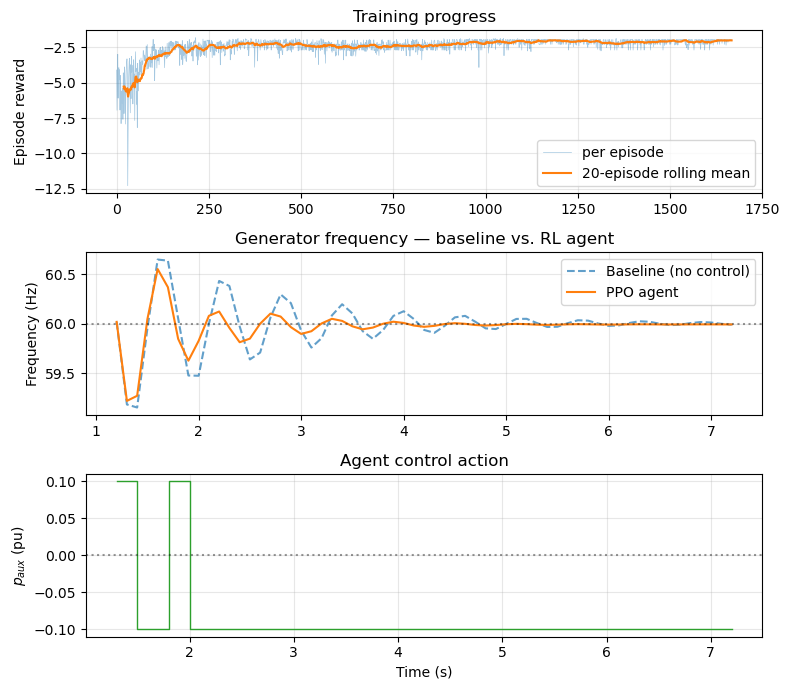

In [17]:
fig, axes = plt.subplots(3, 1, figsize=(8, 7), sharex=False)

# (a) Training curve
ax = axes[0]
ax.plot(callback.ep_rewards, linewidth=0.5, alpha=0.4, label="per episode")
win = min(20, len(callback.ep_rewards))
if win > 1:
    rolling = np.convolve(callback.ep_rewards,
                          np.ones(win) / win, mode="valid")
    ax.plot(np.arange(win - 1, len(callback.ep_rewards)), rolling,
            linewidth=1.5, label=f"{win}-episode rolling mean")
ax.set_ylabel("Episode reward")
ax.set_title("Training progress")
ax.legend()
ax.grid(True, alpha=0.3)

# (b) Frequency: baseline vs agent
ax = axes[1]
ax.plot(bl_t, bl_omega * FREQ_NOM, "--", label="Baseline (no control)",
        linewidth=1.5, alpha=0.7)
ax.plot(ag_t, ag_omega * FREQ_NOM, "-", label="PPO agent",
        linewidth=1.5)
ax.axhline(FREQ_NOM, color="k", linestyle=":", alpha=0.4)
ax.set_ylabel("Frequency (Hz)")
ax.set_title("Generator frequency — baseline vs. RL agent")
ax.legend()
ax.grid(True, alpha=0.3)

# (c) Agent actions
ax = axes[2]
ax.step(ag_t[1:], ag_actions, where="post", linewidth=1.0, color="C2")
ax.axhline(0, color="k", linestyle=":", alpha=0.4)
ax.set_ylabel("$p_{aux}$ (pu)")
ax.set_xlabel("Time (s)")
ax.set_title("Agent control action")
ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## Extend This Example

- **Increase training**: 20 000 steps is a minimal run; 100 000+ steps
  with hyperparameter tuning will yield a stronger policy.
- **Richer observation**: add terminal voltage $V_t$ or electrical power
  $P_e$ to give the agent more information about the system state.
- **Multi-machine systems**: replace the SMIB with the IEEE 14-bus or
  39-bus system to learn coordinated damping across multiple generators.
- **Compare with classical PSS**: add an IEEEST stabiliser and overlay
  its response to see whether RL matches classical control design.